<a href="https://colab.research.google.com/github/monasolgi/Computer_vision/blob/main/Metric_Learning_tutorial_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  **Visualizing Embeddings**

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.4200 - loss: 1.5662 - val_accuracy: 0.5176 - val_loss: 1.2292
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6244 - loss: 1.0191 - val_accuracy: 0.6454 - val_loss: 1.0049
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7000 - loss: 0.8402 - val_accuracy: 0.6728 - val_loss: 0.8920
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.7498 - loss: 0.7420 - val_accuracy: 0.7240 - val_loss: 0.8302
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7918 - loss: 0.6503 - val_accuracy: 0.7558 - val_loss: 0.8282
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8098 - loss: 0.5859 - val_accuracy: 0.7696 - val_loss: 0.7694
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8394 - loss: 0.5365 - val_accuracy: 0.7780 - val_loss: 0.7570
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8580 - loss: 0.487

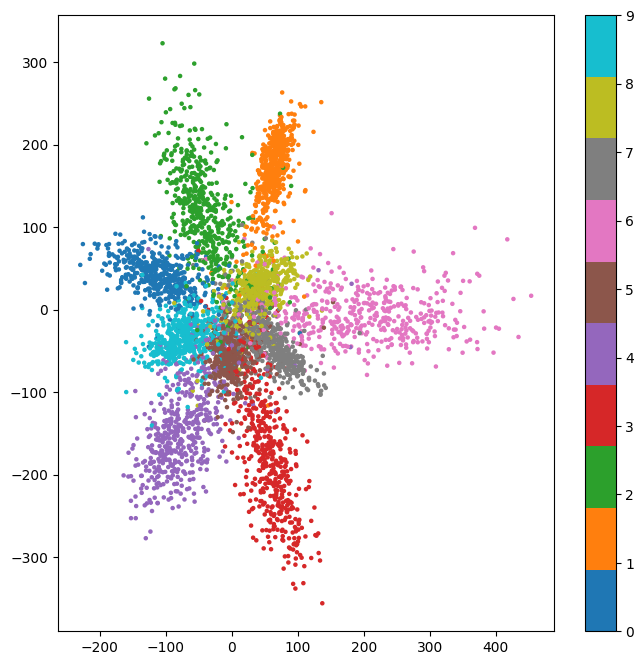

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

batch_size = 8

@tf.function
def categorical_cross_entropy(y_true, y_pred):
    epsilon= 1e-7 # to avoid log(0)
    calss_one_hot=-(y_true * tf.math.log(y_pred + epsilon))#(batch size,classes)
    true_class=tf.reduce_sum(calss_one_hot, axis=1) # keeps only the true class loss for each image (batch size, 1)
    L=tf.reduce_mean(true_class,axis=0) #a scalar , mean over rows, all instances
    return L
# Build a simple CNN with strided convolution layers
def define_model(include_class_layer):
    inputs = tf.keras.Input(shape=(28,28,1),name='Inputs')
    x = layers.Conv2D(16,kernel_size=(5,5),activation='relu',padding='same',strides=1,name='L1')(inputs)
    x = layers.Conv2D(16,kernel_size=(3,3),activation='relu',padding='same',strides=2,name='L2')(x)
    x = layers.Conv2D(16,kernel_size=(3,3),activation='relu',padding='same',strides=1,name='L3')(x)
    x = layers.Conv2D(16,kernel_size=(3,3),activation='relu',padding='same',strides=2,name='L4')(x)
    x = layers.Flatten()(x) # (batch size, 784)

    embedding = layers.Dense(2,name="embedding")(x) # (batch size, 2) meaning each image represnted by (x,y)

    outputs = layers.Dense(10,activation='softmax')(embedding)
    model = keras.Model(inputs=inputs, outputs=outputs)

    return model


def mnist_data():
    (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

    y_train = tf.keras.utils.to_categorical(y_train)
    y_test = tf.keras.utils.to_categorical(y_test)

    x_train = x_train/255.0
    x_test = x_test/255.0

    return x_train, y_train, x_test, y_test

data_slice=5000
x_train, y_train, x_test, y_test=mnist_data()

x_train=x_train[:data_slice,:]
x_train=x_train.reshape(-1, 28, 28, 1) # Reshape to add channel dimension
y_train=y_train[:data_slice,:]

x_test=x_test[:data_slice,:]
x_test=x_test.reshape(-1, 28, 28, 1) # Reshape to add channel dimension
y_test=y_test[:data_slice,:]

model=define_model(True)

model.compile(optimizer="Adam",
              loss=categorical_cross_entropy,
              metrics=['accuracy'])

model.fit(x_train, y_train, batch_size=batch_size
          , epochs=100, validation_data=(x_test, y_test))

embedding=keras.Model(inputs=model.input,
                      outputs=model.get_layer("embedding").output)
#here embedding is a keras mode
#uses the same weight as full model with softmax

embeddings=embedding.predict(x_test)
print("emb:", embedding, type(embedding))

labels=np.argmax(y_test,axis=1)

plt.figure(figsize=(8,8))
plt.scatter(embeddings[:,0], # x coordinate
            embeddings[:,1], # y coordinate
            c=labels, cmap='tab10',
            s=5)
plt.colorbar()
plt.show()

#
#
#loss,accuracy=model.evaluate(x_test, y_test) # Corrected evaluate call
#print("Loss: ", loss)
#print("Accuracy: ", accuracy)

# **Pytorch version**

In [ ]:
import torchvision

train_set=torchvision.datasets.FashionMNIST(root='./data',download=True)


In [ ]:
print(len(train_set), type(train_set))

60000 <class 'torchvision.datasets.mnist.FashionMNIST'>


In [1]:
import torch.nn as nn
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import torchvision.transforms as transforms
import torch.nn.functional as F
import torch.optim as optim

batch_size = 8

def categorical_cross_entropy(y_true, y_pred):
    epsilon= 1e-7 # to avoid log(0)
    class_one_hot=-(y_true * torch.log(y_pred + epsilon))#(batch size,classes)
    true_class=torch.sum(class_one_hot, axis=1) # keeps only the true class loss for each image (batch size, 1)
    L=torch.mean(true_class,axis=0) #a scalar , mean over rows, all instances
    return L
# Build a simple CNN with strided convolution layers
class define_model(nn.Module):
    def __init__(self):
        super(define_model, self).__init__()
        self.L1=nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=2)
        self.L2=nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, stride=2, padding=1)
        self.L3=nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.L4=nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, stride=2, padding=1)
        self.embedding=nn.Linear(in_features=7*7*16, out_features=2)
        self.classifier=nn.Linear(2,10)

    def forward(self,x):
        x=F.relu(self.L1(x))
        x=F.relu(self.L2(x))
        x=F.relu(self.L3(x))
        x=F.relu(self.L4(x))
        x=torch.flatten(x, start_dim=1)
        #flatten everything from dimension 1 onward in(batch,channels,h,w)
        #(8,16*7*7)
        embeddings=self.embedding(x)
        #don't use softmax before nn.crossentropyloss
        digits=self.classifier(embeddings)
        probs=F.softmax(digits,dim=1)


        return probs,embeddings


def mnist_data():
    transform = transforms.Compose(
    [transforms.ToTensor()]
    )

    data_slice=5000

    trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)

    trainset=torch.utils.data.Subset(trainset, range(data_slice))

    trainloader = torch.utils.data.DataLoader(trainset, batch_size=8,
                                          shuffle=True, num_workers=2)

    testset = torchvision.datasets.MNIST(root='./data', train=False,
                                         download=True, transform=transform)

    testset=torch.utils.data.Subset(testset, range(data_slice))

    testloader = torch.utils.data.DataLoader(testset, batch_size=8,
                                           shuffle=False, num_workers=2)


    return trainset, trainloader, testset, testloader

trainset, trainloader, testset, testloader=mnist_data()

#pytorch uses (batch, 1, 28, 28)
#no need to reshape
model=define_model()

#criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

for epoch in range(100):

    running_loss = 0.0

    for i, data in enumerate(trainloader):

        inputs, labels = data
        outputs,emb=model(inputs)
        #to use my defined cross entropy I need one-hot vectors
        one_hot_labels=F.one_hot(labels,num_classes=10).float()
        #to float for multipling in the loss func
        loss=categorical_cross_entropy(one_hot_labels, outputs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(trainloader)}")


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.65MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.4MB/s]


Epoch 1, Loss: 1.542070550775528
Epoch 2, Loss: 1.0125073692560196
Epoch 3, Loss: 0.8200045509338378
Epoch 4, Loss: 0.6948249012947082
Epoch 5, Loss: 0.6067043582379817
Epoch 6, Loss: 0.5371527441322803
Epoch 7, Loss: 0.5007574985861778
Epoch 8, Loss: 0.46188057479858396
Epoch 9, Loss: 0.4147545056223869
Epoch 10, Loss: 0.39176847607791426
Epoch 11, Loss: 0.3618591598808765
Epoch 12, Loss: 0.32791774034649135
Epoch 13, Loss: 0.3161328585855663
Epoch 14, Loss: 0.2945172654300928
Epoch 15, Loss: 0.27339186830222606
Epoch 16, Loss: 0.24434533446878196
Epoch 17, Loss: 0.24116269555538894
Epoch 18, Loss: 0.22524962219782174
Epoch 19, Loss: 0.2022602300323546
Epoch 20, Loss: 0.20157539707683028
Epoch 21, Loss: 0.20317538409642874
Epoch 22, Loss: 0.18263685530386864
Epoch 23, Loss: 0.16383415066860615
Epoch 24, Loss: 0.1662615944229532
Epoch 25, Loss: 0.15969453607229517
Epoch 26, Loss: 0.15143189346268773
Epoch 27, Loss: 0.14381530253170058
Epoch 28, Loss: 0.14445788447083904
Epoch 29, Loss:

# **Visualizing Embeddings**

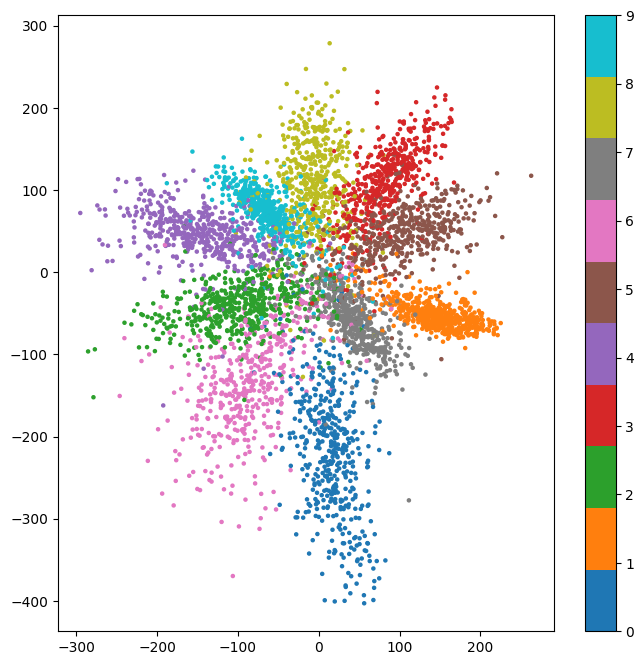

In [9]:
model.eval()

running_loss = 0.0
embedding_list=[]
label_list=[]

with torch.no_grad():
  for i, data in enumerate(testloader):
      inputs, labels = data
      outputs,emb=model(inputs)
      #emb is a tensor(batch_size,2)
      embedding_list.append(emb)
      label_list.append(labels)
#we need to concatenate emb of all batches
#and convert tensor to numpy
embeddings=torch.cat(embedding_list,dim=0).numpy()
labels=torch.cat(label_list,dim=0).numpy()

plt.figure(figsize=(8,8))
plt.scatter(embeddings[:,0], # x coordinate
            embeddings[:,1], # y coordinate
            c=labels, cmap='tab10',
            s=5)
plt.colorbar()
plt.show()

##  **Implementing Contrastive loss**

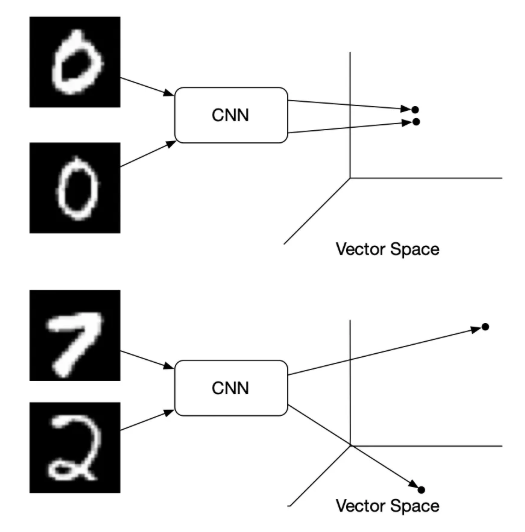

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 10.4600 - val_loss: 6.8453
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5.8639 - val_loss: 5.4204
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 4.8352 - val_loss: 4.9417
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 4.4803 - val_loss: 4.8057
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 4.2132 - val_loss: 4.5342
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 4.0264 - val_loss: 4.3226
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 3.8028 - val_loss: 4.1402
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 3.7613 - val_loss: 3.9910
Epoch 9/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 3.3910 - val_loss: 3.9255
Epoch 10/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 3.4557 - val_loss: 3.8104
Epoch 11/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 3.2558 - val_l

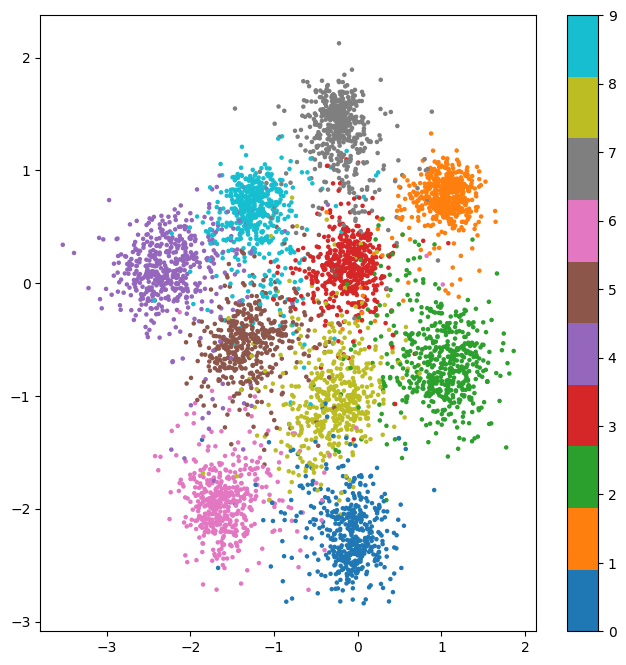

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

batch_size = 8

@tf.function
def contrastive_loss(y_true, y_pred):

  #loss is done in every batch
  L=0
  alpha=1

  n=len(y_pred)
  labels=tf.argmax(y_true,axis=1) #to convert one-hot-vectors into labels

  for i in range(n):
    for j in range(i+1,n):

      D= tf.reduce_sum(tf.square(y_pred[i] - y_pred[j]))

      if labels[i]==labels[j]:
        L+=D
      else:
        L+=tf.maximum(0.0,alpha - D)

  return L
# Build a simple CNN with strided convolution layers
def define_model(include_class_layer):
    inputs = tf.keras.Input(shape=(28,28,1),name='Inputs')
    x = layers.Conv2D(16,kernel_size=(5,5),activation='relu',padding='same',strides=1,name='L1')(inputs)
    x = layers.Conv2D(16,kernel_size=(3,3),activation='relu',padding='same',strides=2,name='L2')(x)
    x = layers.Conv2D(16,kernel_size=(3,3),activation='relu',padding='same',strides=1,name='L3')(x)
    x = layers.Conv2D(16,kernel_size=(3,3),activation='relu',padding='same',strides=2,name='L4')(x)
    x = layers.Flatten()(x) # (batch size, 784)

    embedding = layers.Dense(2,name="embedding")(x) # (batch size, 2) meaning each image represnted by (x,y)

    model = keras.Model(inputs=inputs, outputs=embedding)

    return model


def mnist_data():
    (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

    y_train = tf.keras.utils.to_categorical(y_train)
    y_test = tf.keras.utils.to_categorical(y_test)

    x_train = x_train/255.0
    x_test = x_test/255.0

    return x_train, y_train, x_test, y_test

data_slice=5000
x_train, y_train, x_test, y_test=mnist_data()

x_train=x_train[:data_slice,:]
x_train=x_train.reshape(-1, 28, 28, 1) # Reshape to add channel dimension
y_train=y_train[:data_slice,:]

x_test=x_test[:data_slice,:]
x_test=x_test.reshape(-1, 28, 28, 1) # Reshape to add channel dimension
y_test=y_test[:data_slice,:]

model=define_model(True)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss=contrastive_loss,
              metrics=[] #assification accuracy does not make sense anymore (batch size,2)
             )

model.fit(x_train, y_train, batch_size=batch_size
          , epochs=100, validation_data=(x_test, y_test))

embedding=keras.Model(inputs=model.input,
                      outputs=model.get_layer("embedding").output)
#here embedding is a keras mode
#uses the same weight as full model with softmax

embeddings=embedding.predict(x_test)
print("emb:", embedding, type(embedding))

labels=np.argmax(y_test,axis=1)

plt.figure(figsize=(8,8))
plt.scatter(embeddings[:,0], # x coordinate
            embeddings[:,1], # y coordinate
            c=labels, cmap='tab10',
            s=5)
plt.colorbar()
plt.show()
